Filtered out delays above 0.17 seconds (top 5%)
Remaining messages: 2090


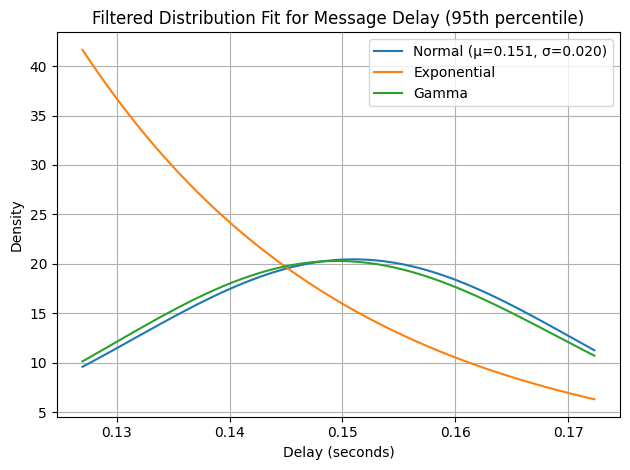

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Load CSV
csv_path = 'results_metrics/result_consumer_pod-0_proc-0.csv'

# Removing top 5% of delays
threshold = df['delay_sec'].quantile(0.95)
df_filtered = df[df['delay_sec'] <= threshold]

# Taking first 5000 rows from filtered data
df_filtered = df_filtered.head(5000)


print(f"Filtered out delays above {threshold:.2f} seconds (top 5%)")
print(f"Remaining messages: {len(df_filtered)}")

# Plotting filtered delay distribution
#plt.figure(figsize=(12, 6))
#sns.histplot(df_filtered['delay_sec'], kde=True, stat='density', bins=30, color='steelblue', label='Histogram + KDE')

# Fitting normal distribution
mu, std = stats.norm.fit(df_filtered['delay_sec'])
x = np.linspace(df_filtered['delay_sec'].min(), df_filtered['delay_sec'].max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, std), label=f'Normal (μ={mu:.3f}, σ={std:.3f})')

# Fitting exponential distribution
loc_exp, scale_exp = stats.expon.fit(df_filtered['delay_sec'])
plt.plot(x, stats.expon.pdf(x, loc_exp, scale_exp), label='Exponential')

# Fitting gamma distribution
a_gamma, loc_gamma, scale_gamma = stats.gamma.fit(df_filtered['delay_sec'])
plt.plot(x, stats.gamma.pdf(x, a_gamma, loc=loc_gamma, scale=scale_gamma), label='Gamma')

plt.title("Filtered Distribution Fit for Message Delay (95th percentile)")
plt.xlabel("Delay (seconds)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


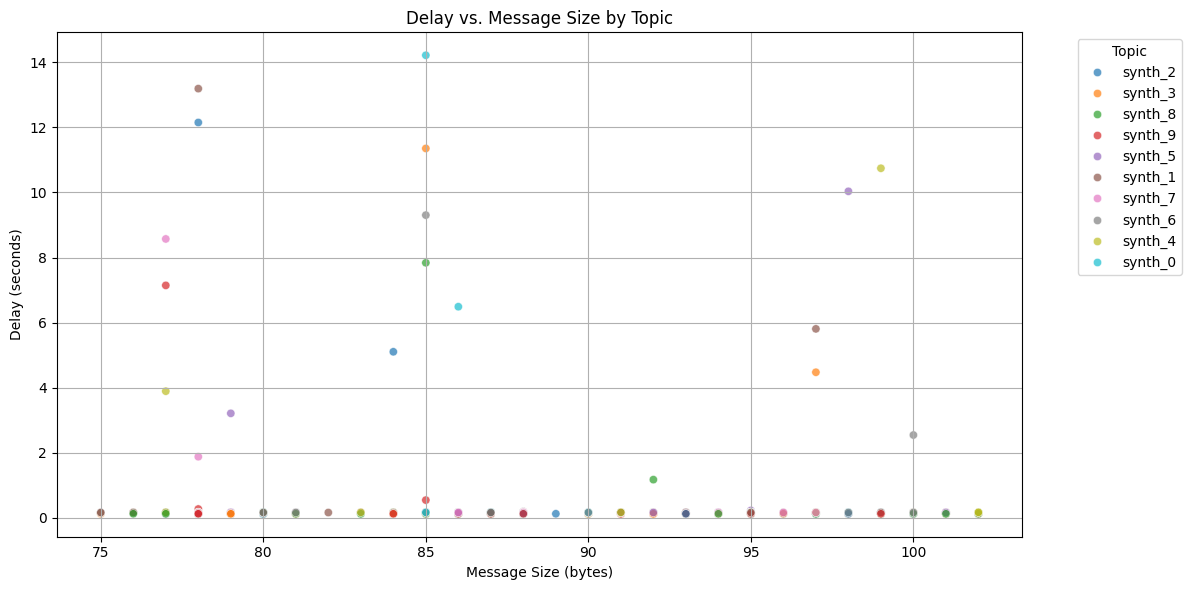

In [39]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='size_bytes', y='delay_sec', hue='topic', palette='tab10', alpha=0.7)

plt.title('Delay vs. Message Size by Topic')
plt.xlabel('Message Size (bytes)')
plt.ylabel('Delay (seconds)')
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Shapiro–Wilk test p-value: 0.00000
Delay is not normal (reject H0)


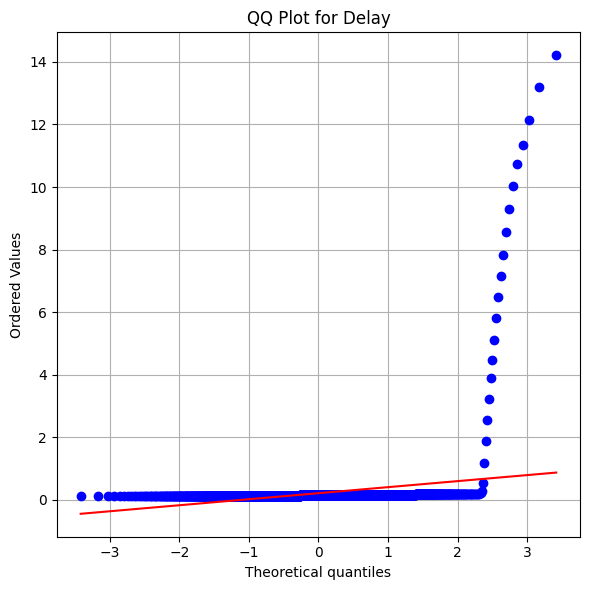

In [40]:
from scipy.stats import shapiro, probplot
import matplotlib.pyplot as plt

# Shapiro–Wilk test
stat, p = shapiro(df['delay_sec'])
print(f"Shapiro–Wilk test p-value: {p:.5f}")
if p > 0.05:
    print("Delay is likely normal (fail to reject H0)")
else:
    print("Delay is not normal (reject H0)")

# QQ Plot
plt.figure(figsize=(6, 6))
probplot(df['delay_sec'], dist="norm", plot=plt)
plt.title("QQ Plot for Delay")
plt.grid(True)
plt.tight_layout()
plt.show()
